# U-net

Segmentación semántica

<img src="./misc/u-net-architecture.png" width="75%">

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms, utils
from torchvision.io import read_file, decode_jpeg, decode_png, ImageReadMode
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torchvision.io import read_image
import zipfile
import time


In [2]:
import os



class Dataset(Dataset):
    def __init__(self, data_dir, label_dir):
        self.data_dir = data_dir
        self.label_dir = label_dir
        self.files = [os.path.splitext(f)[0] for f in os.listdir(data_dir)]
        self.transform = T.Resize((512, 512))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_name = self.files[idx]

        image = read_image(os.path.join(self.data_dir, file_name + ".png"), mode=ImageReadMode.RGB)


        mask = read_image(os.path.join(self.label_dir, file_name + ".png"), mode=ImageReadMode.GRAY)

        image = self.transform(image)
        mask = self.transform(mask)

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.float32)

        image = image / 255.0
        mask /= 255.0
        mask = torch.round(mask)

        return image, mask


zip_path = "/content/archive (5).zip"
extract_dir = "/content/archive (5)"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)



In [21]:
#ds = Dataset("/content/archive (5)/unet/images", "/content/archive (5)/unet/labels")
ds = Dataset("/content/archive (5)/unet/test", "/content/archive (5)/unet/labels")
ds_loader = DataLoader(ds, batch_size=4)

In [25]:
import torch
import torch.nn as nn

""" Convolutional block:
    It follows a two 3x3 convolutional layer, each followed by a batch normalization and a relu activation.
"""
class conv_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_c)

        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_c)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

""" Encoder block:
    A conv_block followed by a max pooling operation.
"""
class encoder_block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = conv_block(in_c, out_c)
        self.pool = nn.MaxPool2d((2, 2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)
        return x, p
""" Decoder block:
    - Upsampling with transpose convolution.
    - Concatenation with the skip connection (if not removed).
    - Convolutional processing.
"""
class decoder_block(nn.Module):
    def __init__(self, in_c, out_c, use_skip):
        super().__init__()

        self.use_skip = use_skip
        self.up = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2, padding=0)

        self.conv = conv_block(out_c * 2 if use_skip == True else out_c, out_c)

    def forward(self, inputs, skip):
        x = self.up(inputs)

        if self.use_skip == True:
            x = torch.cat([x, skip], axis=1)

        x = self.conv(x)
        return x

class build_unet(nn.Module):
    def __init__(self, base_channels, skip_mask):
        super().__init__()

        self.skip_mask = skip_mask

        self.e1 = encoder_block(3, base_channels)
        self.e2 = encoder_block(base_channels, base_channels + 1)
        self.e3 = encoder_block(base_channels + 1, base_channels + 2)
        self.e4 = encoder_block(base_channels + 2, base_channels + 3)

        self.b = conv_block(base_channels + 3, base_channels + 4)

        self.d1 = decoder_block(base_channels + 4, base_channels + 3, use_skip=skip_mask[3])
        self.d2 = decoder_block(base_channels + 3, base_channels + 2, use_skip=skip_mask[2])
        self.d3 = decoder_block(base_channels + 2, base_channels + 1, use_skip=skip_mask[1])
        self.d4 = decoder_block(base_channels + 1, base_channels, use_skip=skip_mask[0])

        self.outputs = nn.Conv2d(base_channels, 1, kernel_size=1,padding=0)

    def forward(self, inputs):
        """ Encoder """
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        """ Bottleneck """
        b = self.b(p4)

        """ Decoder """
        d1 = self.d1(b, s4 if self.skip_mask[3] == True else None)
        d2 = self.d2(d1, s3 if self.skip_mask[2] == True else None)
        d3 = self.d3(d2, s2 if self.skip_mask[1] == True else None)
        d4 = self.d4(d3, s1 if self.skip_mask[0] == True else None)

        """ Classifier """
        outputs = self.outputs(d4)

        return outputs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

skip_connections = [True,True,True,True]
#inputs = torch.randn((2, 3, 512, 512)).to(device)
model = build_unet(base_channels = 4,skip_mask=skip_connections).to(device)
#y = model(inputs)
#print(y.shape)



In [26]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3,
                             weight_decay=1e-5)

In [27]:
num_epochs = 200

for epoch in range(num_epochs):
    for idx, (images, labels) in enumerate(ds_loader):
        outputs = model(images.to(device))
        loss = criterion(outputs, labels.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print("Lote:", idx)

    print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')



<ipython-input-2-c32695e2cf94>:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
<ipython-input-2-c32695e2cf94>:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


Lote: 0
Epoch [1/200], Loss: 0.8781
Lote: 0
Epoch [2/200], Loss: 0.8325
Lote: 0
Epoch [3/200], Loss: 0.7866
Lote: 0
Epoch [4/200], Loss: 0.7372
Lote: 0
Epoch [5/200], Loss: 0.6823
Lote: 0
Epoch [6/200], Loss: 0.6236
Lote: 0
Epoch [7/200], Loss: 0.5608
Lote: 0
Epoch [8/200], Loss: 0.5020
Lote: 0
Epoch [9/200], Loss: 0.4493
Lote: 0
Epoch [10/200], Loss: 0.4052
Lote: 0
Epoch [11/200], Loss: 0.3702
Lote: 0
Epoch [12/200], Loss: 0.3441
Lote: 0
Epoch [13/200], Loss: 0.3245
Lote: 0
Epoch [14/200], Loss: 0.3093
Lote: 0
Epoch [15/200], Loss: 0.2966
Lote: 0
Epoch [16/200], Loss: 0.2855
Lote: 0
Epoch [17/200], Loss: 0.2755
Lote: 0
Epoch [18/200], Loss: 0.2666
Lote: 0
Epoch [19/200], Loss: 0.2586
Lote: 0
Epoch [20/200], Loss: 0.2512
Lote: 0
Epoch [21/200], Loss: 0.2443
Lote: 0
Epoch [22/200], Loss: 0.2378
Lote: 0
Epoch [23/200], Loss: 0.2318
Lote: 0
Epoch [24/200], Loss: 0.2262
Lote: 0
Epoch [25/200], Loss: 0.2210
Lote: 0
Epoch [26/200], Loss: 0.2161
Lote: 0
Epoch [27/200], Loss: 0.2115
Lote: 0
Ep

El unet con los canales simplificados es mas rapido que el unet original.
El unet quitando los skips empeora la calidad de la imagen resultante

<ipython-input-2-f9100562a6ff>:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image, dtype=torch.float32)
<ipython-input-2-f9100562a6ff>:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


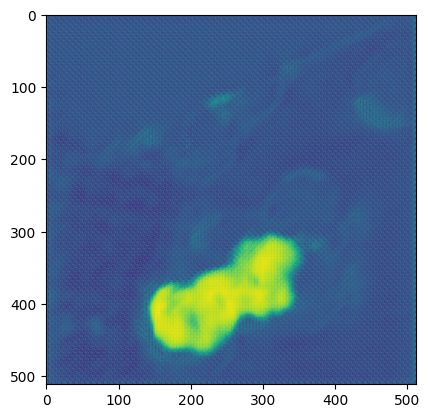

In [ ]:
it = iter(ds_loader)
img, label = next(it)

model.eval()

ret = model(img.to(device))
plt.imshow(ret[1][0].detach().cpu().numpy())

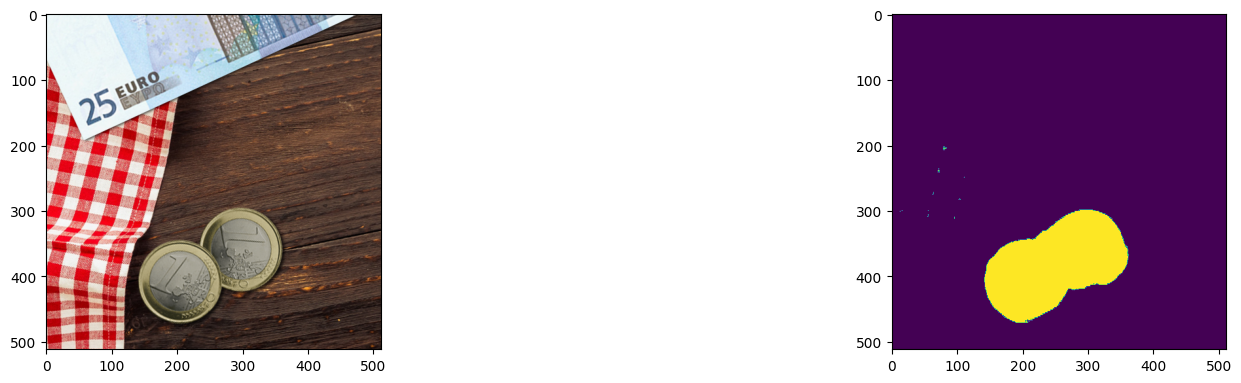

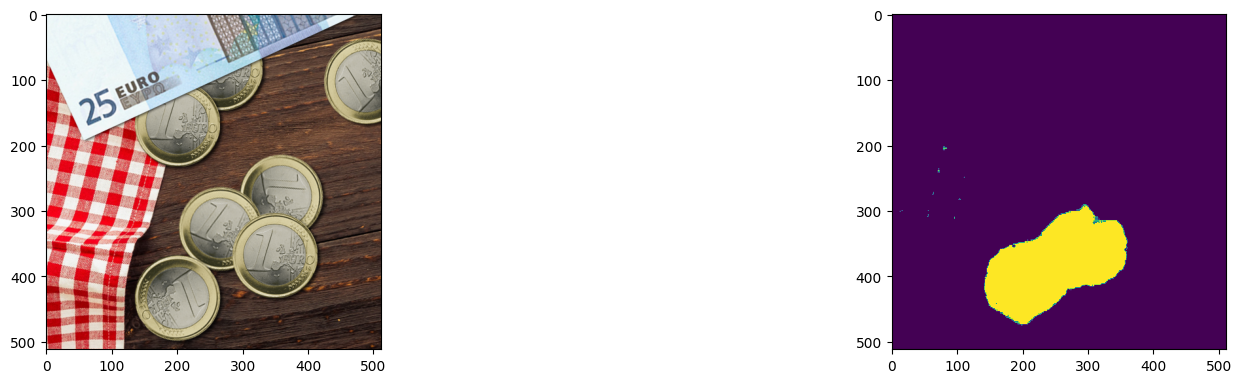

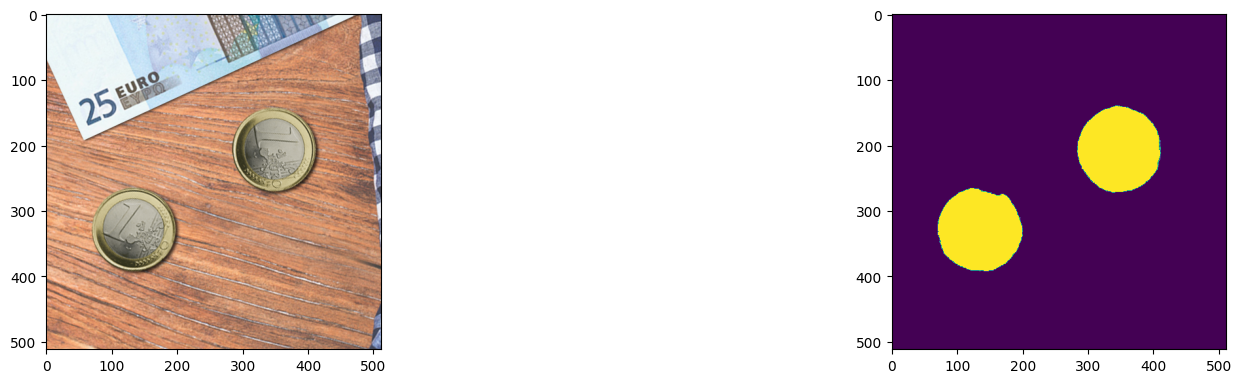

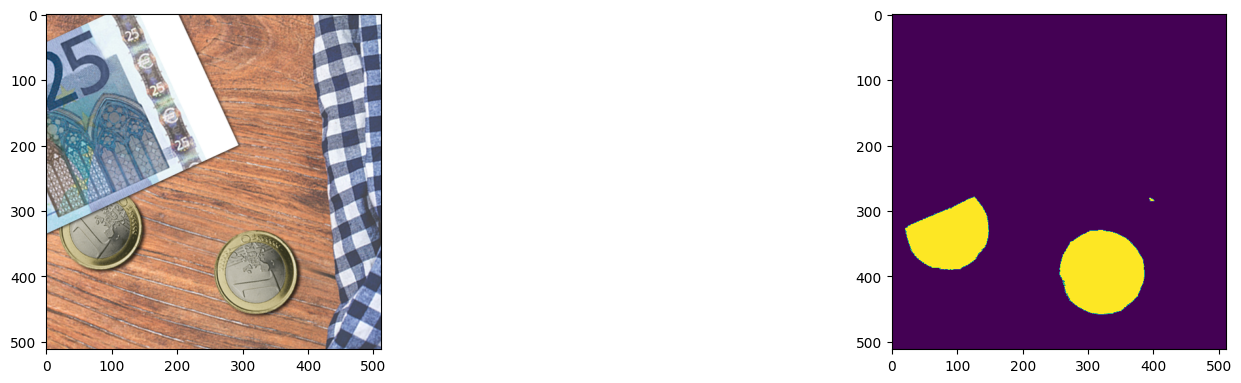

In [ ]:

ret = torch.round(ret)

for i in range(4):

    plt.figure(figsize=(20, 20))
    plt.subplot(4, 2, 2*i+1)
    plt.imshow(img[i].permute(1, 2, 0).detach().cpu().numpy())
    plt.subplot(4, 2, 2*i+2)
    plt.imshow(ret[i][0].detach().cpu().numpy())
